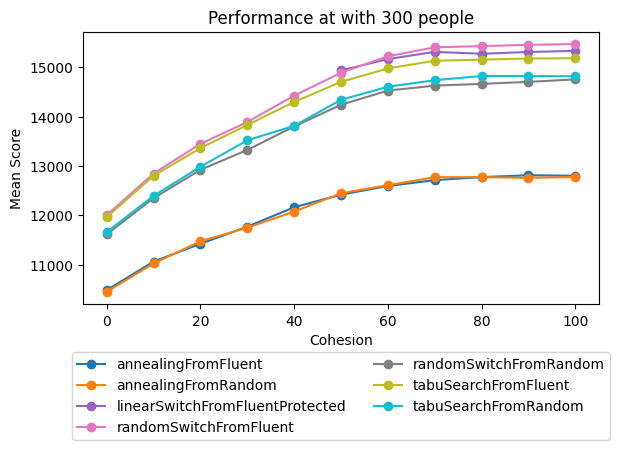

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

people = 300
algorithm_colors = {
    "annealingFromFluent": "tab:blue",
    "annealingFromRandom": "tab:orange",
    "bruteForce": "tab:green",
    "linearSwitchFromFluent": "tab:red",
    "linearSwitchFromFluentProtected": "tab:purple",
    "linearSwitchFromRandom": "tab:brown",
    "randomSwitchFromFluent": "tab:pink",
    "randomSwitchFromRandom": "tab:gray",
    "tabuSearchFromFluent": "tab:olive",
    "tabuSearchFromRandom": "tab:cyan",
}

df = pd.read_csv('flattened_composite_experiments_data.csv')

# Convert score and time to numeric types, coercing invalid values to NaN
df['score'] = pd.to_numeric(df['score'], errors='coerce')
df['time'] = pd.to_numeric(df['time'], errors='coerce')

# Remove rows with NaN values
df = df.dropna()

# print(df)

summary = df.groupby(["algorithm", "n_people", "cohesion"]).agg(
    mean_score=("score", "mean"),
    std_score=("score", "std"),
    mean_time=("time", "mean"),
    std_time=("time", "std"),
).reset_index()

summary_c0 = summary[summary["n_people"] == people]

# print(summary)

pivot_data = summary_c0.pivot(
    index="cohesion",
    columns="algorithm",
    values="mean_score"
)

# Filter colors to only include algorithms in the pivot table
colors = {algo: algorithm_colors.get(algo, "tab:gray") for algo in pivot_data.columns}

pivot_data.plot(
    title=f"Performance at with {people} people",
    xlabel="Cohesion",
    ylabel="Mean Score",
    marker="o",
    color=colors
)
plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2
)
plt.tight_layout(rect=[0, 0.01, 1, 1])
plt.savefig(f'plots/{people}p_score_cohesion_plot.png', dpi=300, bbox_inches='tight')
plt.show()

# print("Plot saved as 'performance_plot.png'")
# print(f"Plot shows performance comparison of {len(summary_c0['algorithm'].unique())} algorithms with 100 people across {len(summary_c0['cohesion'].unique())} cohesion levels")


In [2]:
import pandas as pd

# Load data
df = pd.read_csv("flattened_composite_experiments_data.csv")

# Mark DNFs before conversion
df["is_dnf"] = df["score"] == "DNF"

# Convert to numeric (DNF -> NaN)
df["score"] = pd.to_numeric(df["score"], errors="coerce")
df["time"] = pd.to_numeric(df["time"], errors="coerce")

# Group and compute everything
result = df.groupby("algorithm").agg(
    avg_score=("score", "mean"),
    avg_time=("time", "mean"),
    total_runs=("score", "size"),
    dnf_count=("is_dnf", "sum")
)

# Compute percentage
result["dnf_percentage"] = (result["dnf_count"] / result["total_runs"]) * 100

# Optional: valid runs
result["valid_runs"] = result["total_runs"] - result["dnf_count"]

# Sort (optional)
result = result.sort_values(by="avg_score", ascending=False)

# Round for readability
result = result.round({
    "avg_score": 2,
    "avg_time": 4,
    "dnf_percentage": 2
})

print(result)

                                 avg_score  avg_time  total_runs  dnf_count  \
algorithm                                                                     
tabuSearchFromFluent               5339.04   10.4445        4400          4   
linearSwitchFromFluent             5294.38   13.7938        4400          4   
randomSwitchFromFluent             5179.31    2.6120        4400          4   
linearSwitchFromFluentProtected    5175.69    8.9223        4400          4   
linearSwitchFromRandom             5064.94   14.7697        4400          0   
annealingFromFluent                4837.22    2.0187        4400          4   
randomSwitchFromRandom             4813.69    2.8582        4400          0   
tabuSearchFromRandom               4721.85   11.1239        4400          0   
annealingFromRandom                4413.55    2.3459        4400          0   
bruteForce                         2095.07   23.2539        2000          0   

                                 dnf_percentage  va

In [3]:
def analyze_for_n(df, n_people):
    df_n = df[df["n_people"] == n_people].copy()

    df_n["is_dnf"] = df_n["score"] == "DNF"
    df_n["score"] = pd.to_numeric(df_n["score"], errors="coerce")
    df_n["time"] = pd.to_numeric(df_n["time"], errors="coerce")

    result = df_n.groupby("algorithm").agg(
        avg_score=("score", "mean"),
        avg_time=("time", "mean"),
        total_runs=("score", "size"),
        dnf_count=("is_dnf", "sum")
    )

    result["dnf_percentage"] = (result["dnf_count"] / result["total_runs"]) * 100
    result["valid_runs"] = result["total_runs"] - result["dnf_count"]

    return result.sort_values(by="avg_score", ascending=False).round(2)

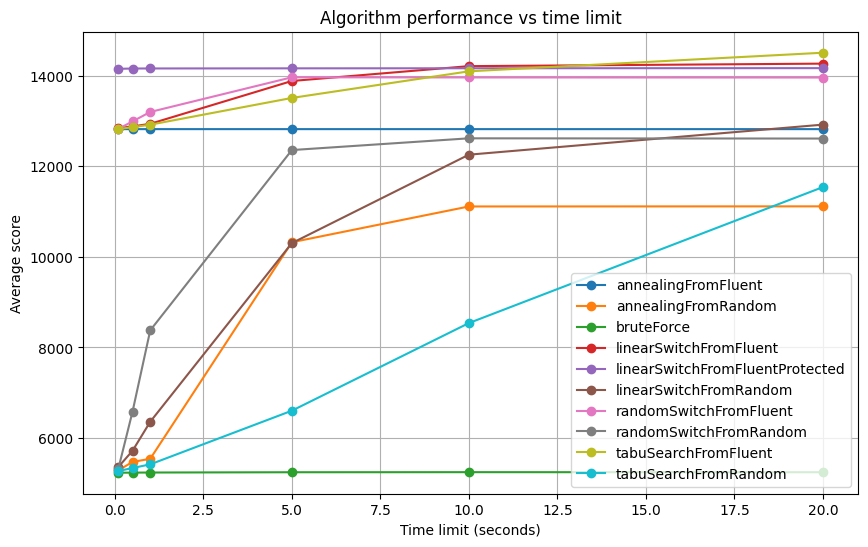

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("flattened_timecomp_experiments_data.csv")

# Ensure numeric types
df["score"] = pd.to_numeric(df["score"], errors="coerce")
df["timelimit"] = pd.to_numeric(df["timelimit"], errors="coerce")

# Drop bad rows
df = df.dropna()

# Group and aggregate
summary = df.groupby(["algorithm", "timelimit"]).agg(
    mean_score=("score", "mean"),
    std_score=("score", "std")
).reset_index()

# Plot
plt.figure(figsize=(10, 6))

for algo in summary["algorithm"].unique():
    subset = summary[summary["algorithm"] == algo]

    # Sort by timelimit (IMPORTANT for correct lines)
    subset = subset.sort_values("timelimit")

    plt.plot(
        subset["timelimit"],
        subset["mean_score"],
        marker="o",
        label=algo
    )

plt.xlabel("Time limit (seconds)")
plt.ylabel("Average score")
plt.title("Algorithm performance vs time limit")
plt.legend()
plt.grid(True)

plt.savefig("plots/time_vs_score.png", dpi=300, bbox_inches="tight")
plt.show()